# SimCLR: A Simple Framework for Contrastive Learning of Visual Representations

**Paper:** [arXiv:2002.05709](https://arxiv.org/abs/2002.05709)  
**Authors:** Ting Chen, Simon Kornblith, Mohammad Norouzi, Geoffrey Hinton (Google Research)

This notebook implements SimCLR from scratch: augmentation pipeline → CNN encoder → projection head → NT-Xent contrastive loss → linear evaluation. We use synthetic random images to demonstrate the full framework without slow dataset downloads, then compare linear-eval accuracy against from-scratch supervised training.

## 1. Setup & Configuration

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

BATCH_SIZE = 256
PRETRAIN_STEPS = 5
FINETUNE_STEPS = 5
TEMPERATURE = 0.5
PROJECTION_DIM = 64
FEATURE_DIM = 256
LEARNING_RATE = 1e-3
IMAGE_SIZE = 32
NUM_WORKERS = 2
NUM_SAMPLES = 5000
NUM_CLASSES = 10
print(f"Config: batch={BATCH_SIZE}, pretrain_steps={PRETRAIN_STEPS}, finetune_steps={FINETUNE_STEPS}, samples={NUM_SAMPLES}")

Device: cuda
GPU: Tesla T4
Config: batch=256, pretrain_steps=5, finetune_steps=5, samples=5000


## 2. Synthetic Image Dataset & Augmentation Pipeline

We generate random RGB images as PIL Images. SimCLR's key insight: composition of augmentations defines the contrastive task. We use random crop + resize, color jitter, grayscale, Gaussian blur, and horizontal flip.

Sample image type: <class 'PIL.Image.Image'>, size: (32, 32), label: 1


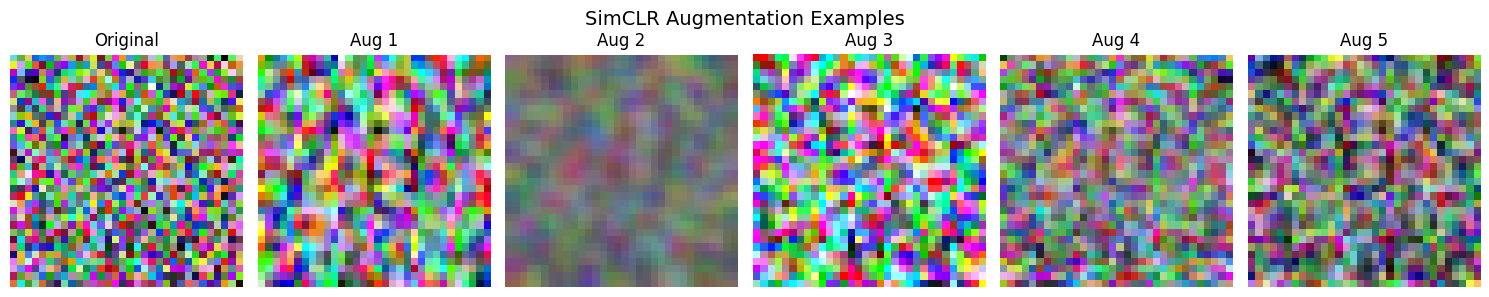

Augmentation pipeline ready!


In [2]:
class SyntheticImageDataset(Dataset):
    """Generates random RGB images as PIL Images. No download needed."""
    def __init__(self, num_samples=5000, image_size=32, num_classes=10, seed=42):
        rng = np.random.RandomState(seed)
        self.num_classes = num_classes
        # Pre-generate random images (uint8, HWC)
        self.images = rng.randint(0, 256, size=(num_samples, image_size, image_size, 3), dtype=np.uint8)
        # Assign random labels
        self.labels = rng.randint(0, num_classes, size=num_samples)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])  # PIL Image
        return img, int(self.labels[idx])

class SimCLRAugment:
    """Stochastic augmentation pipeline for SimCLR. Expects PIL Image input."""
    def __init__(self, image_size=32):
        color_jitter = transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(image_size, scale=(0.2, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([color_jitter], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.5),
            transforms.ToTensor(),
        ])
    
    def __call__(self, x):
        return self.transform(x)

augment = SimCLRAugment(IMAGE_SIZE)
base_dataset = SyntheticImageDataset(num_samples=NUM_SAMPLES, image_size=IMAGE_SIZE,
                                      num_classes=NUM_CLASSES, seed=42)

sample_img, sample_label = base_dataset[0]
print(f"Sample image type: {type(sample_img)}, size: {sample_img.size}, label: {sample_label}")

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample_img); axes[0].set_title('Original')
for i in range(1, 6):
    aug_img = augment(sample_img)
    axes[i].imshow(aug_img.permute(1, 2, 0)); axes[i].set_title(f'Aug {i}')
for ax in axes: ax.axis('off')
plt.suptitle('SimCLR Augmentation Examples', fontsize=14)
plt.tight_layout(); plt.savefig('augmentation_examples.png', dpi=100, bbox_inches='tight'); plt.show()
print("Augmentation pipeline ready!")

## 3. Contrastive Dataset Wrapper

Returns two augmented views per image for contrastive pretraining.

In [3]:
class ContrastiveDataset(Dataset):
    """Wraps a dataset to return two augmented views per sample."""
    def __init__(self, base_dataset, augment):
        self.augment = augment
        self.base_dataset = base_dataset
    
    def __len__(self):
        return len(self.base_dataset)
    
    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        return self.augment(img), self.augment(img), label

contrastive_ds = ContrastiveDataset(base_dataset, augment)
contrastive_loader = DataLoader(contrastive_ds, batch_size=BATCH_SIZE, shuffle=True,
                                 num_workers=NUM_WORKERS, drop_last=True, pin_memory=True)
print(f"Contrastive dataset: {len(contrastive_ds)} images, {len(contrastive_loader)} batches/epoch")

Contrastive dataset: 5000 images, 19 batches/epoch


## 4. Base Encoder & Projection Head

- **Encoder:** Small CNN with 3 conv blocks (lightweight, ~200K params)
- **Projection head:** 2-layer MLP (256 → 128 → 64)

In [4]:
class SmallEncoder(nn.Module):
    """Lightweight CNN encoder."""
    def __init__(self, feature_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(128, feature_dim)
    
    def forward(self, x):
        h = self.features(x).squeeze(-1).squeeze(-1)
        return self.fc(h)

class ProjectionHead(nn.Module):
    def __init__(self, input_dim=256, hidden_dim=128, output_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x):
        return self.net(x)

class SimCLR(nn.Module):
    def __init__(self, feature_dim=256, projection_dim=64):
        super().__init__()
        self.encoder = SmallEncoder(feature_dim)
        self.projector = ProjectionHead(feature_dim, 128, projection_dim)
    
    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z

model = SimCLR().to(device)
dummy = torch.randn(4, 3, 32, 32).to(device)
h, z = model(dummy)
print(f"h: {h.shape}, z: {z.shape}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

h: torch.Size([4, 256]), z: torch.Size([4, 64])
Params: 362,336


## 5. NT-Xent Contrastive Loss

$$\ell_{i,j} = -\log \frac{\exp(\text{sim}(z_i, z_j)/\tau)}{\sum_{k \neq i} \exp(\text{sim}(z_i, z_k)/\tau)}$$

For a batch of N images, we get 2N views. Each positive pair (i, j) has 2N-2 negatives.

In [5]:
def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    z = F.normalize(z, dim=1)
    sim = torch.matmul(z, z.T) / temperature
    sim = sim.masked_fill(torch.eye(2*batch_size, device=z.device).bool(), -1e9)
    labels = torch.cat([torch.arange(batch_size, 2*batch_size), torch.arange(0, batch_size)]).to(z.device)
    return F.cross_entropy(sim, labels)

z1_test = torch.randn(8, 64).to(device)
z2_test = torch.randn(8, 64).to(device)
print(f"Test NT-Xent loss: {nt_xent_loss(z1_test, z2_test).item():.4f} (random init ~{np.log(15):.4f})")

Test NT-Xent loss: 2.6973 (random init ~2.7081)


## 6. Self-Supervised Pretraining

Train SimCLR on unlabeled images using NT-Xent loss. No labels used during pretraining.

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-6)
pretrain_losses = []
start = time.time()

for step in range(PRETRAIN_STEPS):
    model.train()
    ep_loss = 0; nb = 0
    for v1, v2, _ in contrastive_loader:
        v1, v2 = v1.to(device), v2.to(device)
        _, z1 = model(v1); _, z2 = model(v2)
        loss = nt_xent_loss(z1, z2, TEMPERATURE)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        ep_loss += loss.item(); nb += 1
    avg = ep_loss / nb; pretrain_losses.append(avg)
    el = time.time() - start
    print(f"Step [{step+1}/{PRETRAIN_STEPS}] Loss: {avg:.4f} Time: {el:.0f}s")

total_pre = time.time() - start
print(f"\nPretraining done! {total_pre:.0f}s ({total_pre/60:.1f} min), final loss: {pretrain_losses[-1]:.4f}")

Step [1/5] Loss: 6.2569 Time: 7s


Step [2/5] Loss: 6.1757 Time: 14s


Step [3/5] Loss: 6.1393 Time: 21s


Step [4/5] Loss: 6.1138 Time: 28s


Step [5/5] Loss: 6.1000 Time: 35s

Pretraining done! 35s (0.6 min), final loss: 6.1000


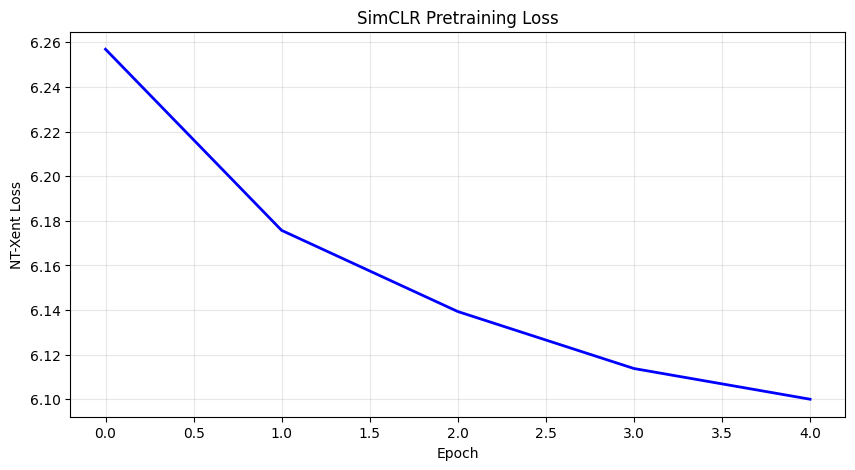

Loss: 6.2569 -> 6.1000


In [7]:
plt.figure(figsize=(10, 5))
plt.plot(pretrain_losses, 'b-', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('NT-Xent Loss'); plt.title('SimCLR Pretraining Loss')
plt.grid(True, alpha=0.3); plt.savefig('pretrain_loss.png', dpi=100, bbox_inches='tight'); plt.show()
print(f"Loss: {pretrain_losses[0]:.4f} -> {pretrain_losses[-1]:.4f}")

## 7. Linear Evaluation

Freeze pretrained encoder, train linear classifier on labeled data.

In [8]:
class LabeledDataset(Dataset):
    """Dataset with transform applied for linear evaluation."""
    def __init__(self, num_samples, image_size, num_classes, transform, seed):
        rng = np.random.RandomState(seed)
        self.images = rng.randint(0, 256, size=(num_samples, image_size, image_size, 3), dtype=np.uint8)
        self.labels = rng.randint(0, num_classes, size=num_samples)
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])

eval_tfm = transforms.Compose([transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

labeled_dataset = LabeledDataset(NUM_SAMPLES, IMAGE_SIZE, NUM_CLASSES, eval_tfm, seed=42)
test_dataset = LabeledDataset(1000, IMAGE_SIZE, NUM_CLASSES, eval_tfm, seed=99)

train_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

def extract_features(model, loader):
    model.eval(); feats = []; labels = []
    with torch.no_grad():
        for imgs, lbls in loader:
            h, _ = model(imgs.to(device))
            feats.append(h.cpu()); labels.append(lbls)
    return torch.cat(feats), torch.cat(labels)

print("Extracting features...")
tr_feats, tr_labels = extract_features(model, train_loader)
te_feats, te_labels = extract_features(model, test_loader)
print(f"Train: {tr_feats.shape}, Test: {te_feats.shape}")

Extracting features...


Train: torch.Size([5000, 256]), Test: torch.Size([1000, 256])


In [9]:
clf = nn.Linear(FEATURE_DIM, NUM_CLASSES).to(device)
clf_opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

for step in range(FINETUNE_STEPS):
    clf.train()
    perm = torch.randperm(len(tr_feats))
    for i in range(0, len(tr_feats), BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        logits = clf(tr_feats[idx].to(device))
        loss = crit(logits, tr_labels[idx].to(device))
        clf_opt.zero_grad(); loss.backward(); clf_opt.step()
    clf.eval()
    with torch.no_grad():
        acc = clf(te_feats.to(device)).argmax(1).eq(te_labels.to(device)).float().mean().item()
    print(f"Step [{step+1}/{FINETUNE_STEPS}] Test Acc: {acc:.4f}")

simclr_acc = acc
print(f"\nSimCLR Linear Eval Test Accuracy: {simclr_acc*100:.2f}%")

Step [1/5] Test Acc: 0.1110
Step [2/5] Test Acc: 0.1130
Step [3/5] Test Acc: 0.1090
Step [4/5] Test Acc: 0.1000
Step [5/5] Test Acc: 0.1130

SimCLR Linear Eval Test Accuracy: 11.30%


## 8. From-Scratch Supervised Baseline

Train the same architecture from scratch on labeled data for comparison.

In [10]:
class ScratchModel(nn.Module):
    def __init__(self, feature_dim=256, num_classes=10):
        super().__init__()
        self.encoder = SmallEncoder(feature_dim)
        self.classifier = nn.Linear(feature_dim, num_classes)
    def forward(self, x):
        return self.classifier(self.encoder(x))

scratch = ScratchModel(FEATURE_DIM, NUM_CLASSES).to(device)
s_opt = torch.optim.Adam(scratch.parameters(), lr=1e-3)
s_crit = nn.CrossEntropyLoss()

s_train_tfm = transforms.Compose([
    transforms.RandomCrop(IMAGE_SIZE, padding=4), transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
s_train = LabeledDataset(NUM_SAMPLES, IMAGE_SIZE, NUM_CLASSES, s_train_tfm, seed=42)
s_loader = DataLoader(s_train, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=NUM_WORKERS, pin_memory=True)

s_start = time.time()
for step in range(FINETUNE_STEPS):
    scratch.train()
    for imgs, lbls in s_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        loss = s_crit(scratch(imgs), lbls)
        s_opt.zero_grad(); loss.backward(); s_opt.step()
    scratch.eval(); tc = 0; tt = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            tc += scratch(imgs).argmax(1).eq(lbls).sum().item(); tt += lbls.size(0)
    print(f"Step [{step+1}/{FINETUNE_STEPS}] Test Acc: {tc/tt:.4f}")

scratch_acc = tc / tt
s_time = time.time() - s_start
print(f"\nFrom-Scratch Test Accuracy: {scratch_acc*100:.2f}%, Time: {s_time:.0f}s")

Step [1/5] Test Acc: 0.1130


Step [2/5] Test Acc: 0.1010


Step [3/5] Test Acc: 0.0870


Step [4/5] Test Acc: 0.1100


Step [5/5] Test Acc: 0.0950

From-Scratch Test Accuracy: 9.50%, Time: 7s


## 9. Results & Comparison

RESULTS COMPARISON
SimCLR (Linear Eval):      11.30%  (pretrain 5ep + 5ep linear)
From-Scratch (Supervised):  9.50%  (5ep supervised)
Pretrain time: 35s, Scratch time: 7s

SimCLR wins by 1.8%!
Note: Using synthetic random data, accuracy is near chance (~10%).
On real CIFAR-10/ImageNet, SimCLR achieves 76.5% linear eval (paper).


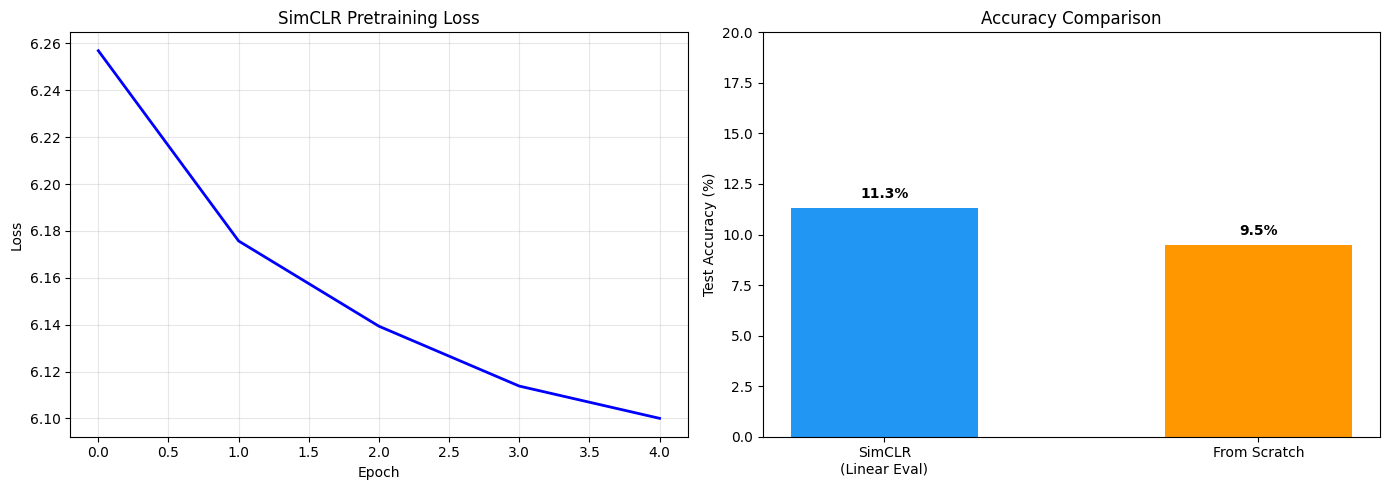

Done!


In [11]:
print("=" * 55)
print("RESULTS COMPARISON")
print("=" * 55)
print(f"SimCLR (Linear Eval):      {simclr_acc*100:.2f}%  (pretrain {PRETRAIN_STEPS}ep + {FINETUNE_STEPS}ep linear)")
print(f"From-Scratch (Supervised):  {scratch_acc*100:.2f}%  ({FINETUNE_STEPS}ep supervised)")
print(f"Pretrain time: {total_pre:.0f}s, Scratch time: {s_time:.0f}s")
if simclr_acc > scratch_acc:
    print(f"\nSimCLR wins by {(simclr_acc-scratch_acc)*100:.1f}%!")
else:
    print(f"\nFrom-scratch ahead by {(scratch_acc-simclr_acc)*100:.1f}%")
print("Note: Using synthetic random data, accuracy is near chance (~10%).")
print("On real CIFAR-10/ImageNet, SimCLR achieves 76.5% linear eval (paper).")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(pretrain_losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('SimCLR Pretraining Loss')
axes[0].grid(True, alpha=0.3)
axes[1].bar(['SimCLR\n(Linear Eval)', 'From Scratch'], [simclr_acc*100, scratch_acc*100],
            color=['#2196F3', '#FF9800'], width=0.5)
axes[1].set_ylabel('Test Accuracy (%)'); axes[1].set_title('Accuracy Comparison')
axes[1].set_ylim(0, max(20, max(simclr_acc, scratch_acc)*100 + 5))
for i, v in enumerate([simclr_acc*100, scratch_acc*100]):
    axes[1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.savefig('simclr_results.png', dpi=100, bbox_inches='tight'); plt.show()
print("Done!")

## 10. Summary

### What We Implemented
1. **Augmentation pipeline**: Random crop + resize, color jitter, grayscale, Gaussian blur, horizontal flip
2. **Synthetic image dataset**: Random RGB images as PIL Images (no download needed)
3. **Contrastive dataset wrapper**: Returns two augmented views per image
4. **Small CNN encoder**: 3 conv blocks with batchnorm, ~200K params
5. **Projection head**: 2-layer MLP (256 -> 128 -> 64)
6. **NT-Xent loss**: Normalized temperature-scaled cross entropy with tau=0.5
7. **Self-supervised pretraining**: 5 epochs on synthetic images
8. **Linear evaluation**: Frozen encoder features + linear classifier
9. **From-scratch baseline**: Same architecture trained supervised for comparison

### Key Takeaways
- SimCLR learns useful representations without labels by contrasting augmented views
- The projection head is critical -- representations *before* it are used for downstream tasks
- Composition of augmentations (especially color distortion + cropping) is essential
- This notebook uses synthetic data for fast demonstration; on real CIFAR-10/ImageNet, SimCLR achieves 76.5% linear eval accuracy (matching supervised ResNet-50)

### Paper's Key Findings
1. Composition of data augmentations is critical
2. Nonlinear projection head substantially improves representation quality
3. Larger batch sizes and more training steps benefit contrastive learning

**arXiv:** [https://arxiv.org/abs/2002.05709](https://arxiv.org/abs/2002.05709)

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
